# Time of Emergence — Three Framings
## GMSAT  |  G6-1.5K-HiLLA vs SSP2-4.5  |  MIROC-ES2H

Three detection methods applied to the same model (MIROC-ES2H, 10 members):

| Panel | Method | Information assumed known |
|---|---|---|
| 1 | **Perfect-model** — Welch's t-test on per-member window means | Both 10-member ensembles |
| 2 | **SSP2-4.5 counterfactual** — cumulative one-sided t-test (all years 2035–Y) | Both 10-member ensembles, tested member-by-member |
| 3 | **Obs-only** — OLS trend + AR(1) prediction interval on single realisation | SSP2-4.5 r01 (2020–2034) as pseudo-obs; HiLLA r01 as the new intervention |

All timeseries are anomalies relative to the 2020–2039 ensemble mean of SSP2-4.5.

In [4]:
import sys
import fsspec
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats

matplotlib.rcParams.update({'font.size': 12})
sys.path.append('../shared/Code_examples/G6-1.5K_example/')
from Utils import weighted_annual_resample

SAI_START  = 2035
ANOM_REF   = (2020, 2039)   # SSP245 ensemble mean reference for anomalies
PLOT_START = 2020
PLOT_END   = 2084
K_CONSEC   = 5              # consecutive years for obs-only ToE
CI_LEVEL   = 0.95
ALPHA      = 0.05
MIN_N      = 5              # minimum years for cumulative t-test
Y_MIN, Y_MAX = 2, 40        # window lengths for perfect-model method

In [5]:
# ── MIROC-ES2H ────────────────────────────────────────────────────────────────
_MIROC = 's3://reflective-persistent-prod-large/MIROC-ES2H/G6-1.5K-HiLLA/Amon'
N_MEM  = 10
miroc_HiLLA_files  = [f'{_MIROC}/tas_G6-1.5K-HiLLA_r{i:02d}.nc' for i in range(1, N_MEM + 1)]
miroc_ssp245_files = [f'{_MIROC}/tas_baseline_r{i:02d}.nc'       for i in range(1, N_MEM + 1)]
print(f'Defined {N_MEM} HiLLA and {N_MEM} SSP245 file paths.')

Defined 10 HiLLA and 10 SSP245 file paths.


In [6]:
def open_nc(path):
    with fsspec.open(path, mode='rb') as f:
        return xr.open_dataset(f, engine='h5netcdf', chunks={}).load()


def global_annual_mean(ds, var='tas', lat_name='lat'):
    """Area-weighted global annual mean; returns DataArray indexed by integer year."""
    da = ds[var]
    if float(da[lat_name][0]) > float(da[lat_name][-1]):
        da = da.sortby(lat_name)
    weights = np.cos(np.deg2rad(da[lat_name]))
    weights /= weights.sum()
    gmean = (da * weights).sum(lat_name).mean('lon')
    annual = weighted_annual_resample(gmean.to_dataset(name=var), var=var)[var]
    return annual.assign_coords(time=annual.time.dt.year.values)


print('Loading MIROC-ES2H...')
miroc_HiLLA_ds  = [open_nc(f) for f in miroc_HiLLA_files]
miroc_ssp245_ds = [open_nc(f) for f in miroc_ssp245_files]
print(f'  HiLLA:  {N_MEM} members, '
      f'{int(miroc_HiLLA_ds[0].time.dt.year.min())}–{int(miroc_HiLLA_ds[0].time.dt.year.max())}')
print(f'  SSP245: {N_MEM} members, '
      f'{int(miroc_ssp245_ds[0].time.dt.year.min())}–{int(miroc_ssp245_ds[0].time.dt.year.max())}')

Loading MIROC-ES2H...
  HiLLA:  10 members, 2035–2084
  SSP245: 10 members, 2020–2084


In [7]:
print('Computing global annual means...')
miroc_HiLLA_gmsat  = [global_annual_mean(ds) for ds in miroc_HiLLA_ds]
miroc_ssp245_gmsat = [global_annual_mean(ds) for ds in miroc_ssp245_ds]

# Anomaly reference: 2020–2039 ensemble mean of SSP245
ref = float(np.mean([
    float(ts.sel(time=slice(*ANOM_REF)).mean())
    for ts in miroc_ssp245_gmsat
]))
print(f'Anomaly reference (SSP245 ens mean {ANOM_REF[0]}–{ANOM_REF[1]}): {ref:.4f} K')

miroc_HiLLA_anom  = [ts - ref for ts in miroc_HiLLA_gmsat]
miroc_ssp245_anom = [ts - ref for ts in miroc_ssp245_gmsat]

# Convenience: stack to (n_members, n_years) arrays for ensemble plots
def stack_ens(ts_list, yr_start=PLOT_START, yr_end=PLOT_END):
    common = sorted(set.intersection(*[set(ts.time.values.tolist()) for ts in ts_list]))
    common = [y for y in common if yr_start <= y <= yr_end]
    return (np.stack([ts.sel(time=common).values for ts in ts_list]),
            np.array(common, dtype=int))

hilla_arr, hilla_yrs = stack_ens(miroc_HiLLA_anom)
ssp_arr,   ssp_yrs   = stack_ens(miroc_ssp245_anom)
print(f'Ensemble arrays: HiLLA {hilla_arr.shape}, SSP245 {ssp_arr.shape}')

Computing global annual means...
Anomaly reference (SSP245 ens mean 2020–2039): 288.7001 K
Ensemble arrays: HiLLA (10, 43), SSP245 (10, 65)


## Method 1 — Perfect-model: fixed-window ensemble t-test
For window length Y, compute each member's mean GMSAT over [2035, 2035+Y−1].
Test if HiLLA means (n=10) are significantly less than SSP2-4.5 means (n=10): Welch's t-test, `alternative='less'`, p < 0.05.
ToE = last year of the first significant window.

In [8]:
y_vals = np.arange(Y_MIN, Y_MAX + 1)

def perfect_model_toe(hilla_list, ssp245_list,
                      start_year=SAI_START, y_vals=y_vals, alpha=ALPHA):
    """Welch's t-test on per-member window means (HiLLA < SSP245)."""
    p_arr = np.full(len(y_vals), np.nan)
    for i, Y in enumerate(y_vals):
        h = [float(ts.sel(time=slice(start_year, start_year + int(Y) - 1)).mean())
             for ts in hilla_list]
        s = [float(ts.sel(time=slice(start_year, start_year + int(Y) - 1)).mean())
             for ts in ssp245_list]
        _, p = stats.ttest_ind(h, s, equal_var=False, alternative='less')
        p_arr[i] = p
    first = np.where(p_arr < alpha)[0]
    toe = int(start_year + y_vals[first[0]] - 1) if len(first) else None
    wlen = int(y_vals[first[0]]) if len(first) else None
    return p_arr, toe, wlen


pm_pvals, pm_toe, pm_wlen = perfect_model_toe(miroc_HiLLA_anom, miroc_ssp245_anom)
print(f'Method 1 (perfect-model)  ToE: {pm_toe}  (window = {pm_wlen} yr)')

Method 1 (perfect-model)  ToE: 2037  (window = 3 yr)


## Method 2 — Cumulative t-test (SSP2-4.5 counterfactual)
For year Y, collect all annual GMSAT values from 2035 to Y in one HiLLA member and its paired SSP2-4.5 member.
One-sided Welch's t-test (HiLLA < SSP245), p < 0.05.  
Member ToE = first significant year.  Model ToE = first year all 10 members are simultaneously significant.

In [9]:
def cumulative_ttest_toe(hilla_ts, ssp245_ts,
                         start_year=SAI_START, alpha=ALPHA, min_n=MIN_N):
    h_yrs = hilla_ts.time.values.astype(int);  h_vals = hilla_ts.values
    s_yrs = ssp245_ts.time.values.astype(int); s_vals = ssp245_ts.values
    h_yrs, h_vals = h_yrs[h_yrs >= start_year], h_vals[h_yrs >= start_year]
    s_yrs, s_vals = s_yrs[s_yrs >= start_year], s_vals[s_yrs >= start_year]
    end_year = int(min(h_yrs.max(), s_yrs.max()))
    p_vals = {}; toe = None
    for Y in range(start_year, end_year + 1):
        h_win = h_vals[h_yrs <= Y]
        s_win = s_vals[s_yrs <= Y]
        if min(len(h_win), len(s_win)) < min_n:
            p_vals[Y] = np.nan; continue
        _, p = stats.ttest_ind(h_win, s_win, equal_var=False, alternative='less')
        p_vals[Y] = p
        if toe is None and p < alpha:
            toe = Y
    return toe, p_vals


cm_mem_toes = []; cm_pvals_all = []
for h, s in zip(miroc_HiLLA_anom, miroc_ssp245_anom):
    toe, pvs = cumulative_ttest_toe(h, s)
    cm_mem_toes.append(toe); cm_pvals_all.append(pvs)

all_years = sorted(set().union(*[set(pv.keys()) for pv in cm_pvals_all]))
cm_toe = next((Y for Y in all_years
               if all(pv.get(Y, np.nan) < ALPHA for pv in cm_pvals_all)), None)

print(f'Method 2 (cumulative t-test)  member ToEs: {cm_mem_toes}')
print(f'Method 2 (cumulative t-test)  model  ToE:  {cm_toe}')

Method 2 (cumulative t-test)  member ToEs: [2041, 2039, 2039, 2042, 2039, 2039, 2039, 2041, 2039, 2040]
Method 2 (cumulative t-test)  model  ToE:  2042


## Method 3 — Obs-only: OLS trend + AR(1) prediction interval
Train an OLS linear trend on MIROC-ES2H SSP2-4.5 r01 (2020–2034) as pseudo-observations.
Fit AR(1) to residuals and extrapolate a 95% prediction interval from 2035 onward.
ToE = first year GMSAT_HiLLA_r01 falls **below** the lower PI bound for K=5 consecutive years.

In [10]:
PRED_YEARS = np.arange(SAI_START, PLOT_END + 1)


def ar1_forecast(obs_ts, pred_years, ci=CI_LEVEL):
    """OLS linear trend + AR(1) residuals h-step forecast.

    Returns (mu, lower_ci, upper_ci) over pred_years.
    """
    x_fit = obs_ts.time.values.astype(float)
    y_fit = obs_ts.values.astype(float)
    slope, intercept, *_ = stats.linregress(x_fit, y_fit)
    resid  = y_fit - (slope * x_fit + intercept)
    phi    = np.dot(resid[1:], resid[:-1]) / np.dot(resid[:-1], resid[:-1])
    innov  = resid[1:] - phi * resid[:-1]
    sigma  = np.sqrt(np.sum(innov**2) / (len(innov) - 1))
    eps_last = resid[-1]
    h   = pred_years.astype(float) - x_fit[-1]
    mu  = slope * pred_years + intercept + phi**h * eps_last
    z       = stats.norm.ppf((1 + ci) / 2)
    pi_half = z * sigma * np.sqrt((1 - phi**(2*h)) / max(1 - phi**2, 1e-8))
    print(f'  OLS slope : {slope:.4f} K/yr  |  AR(1) phi={phi:.3f},  sigma={sigma:.4f} K')
    return mu, mu - pi_half, mu + pi_half


def ar1_toe_lower(hilla_ts, pred_years, lower_pi,
                  start_year=SAI_START, K=K_CONSEC):
    """First year HiLLA is below lower PI for K consecutive years."""
    h_yrs  = hilla_ts.time.values
    common = np.intersect1d(h_yrs[h_yrs >= start_year], pred_years)
    if len(common) < K:
        return None
    h_vals = hilla_ts.sel(time=common).values
    lo     = lower_pi[np.searchsorted(pred_years, common)]
    below  = h_vals < lo
    for i in range(len(below) - K + 1):
        if below[i: i + K].all():
            return int(common[i])
    return None


# SSP245 r01, 2020–2034 only (pre-SAI pseudo-obs)
obs_r01 = miroc_ssp245_anom[0].sel(time=slice(2020, SAI_START - 1))

print('AR(1) forecast from SSP245 r01 (2020–2034):')
ar1_mu, ar1_lo, ar1_hi = ar1_forecast(obs_r01, PRED_YEARS)

obs_toe = ar1_toe_lower(miroc_HiLLA_anom[0], PRED_YEARS, ar1_lo)
print(f'Method 3 (obs-only)  ToE: {obs_toe}  (K={K_CONSEC} consecutive years below lower {int(CI_LEVEL*100)}% PI)')

AR(1) forecast from SSP245 r01 (2020–2034):
  OLS slope : 0.0469 K/yr  |  AR(1) phi=0.474,  sigma=0.1635 K
Method 3 (obs-only)  ToE: 2039  (K=5 consecutive years below lower 95% PI)


## Figure — three-panel comparison

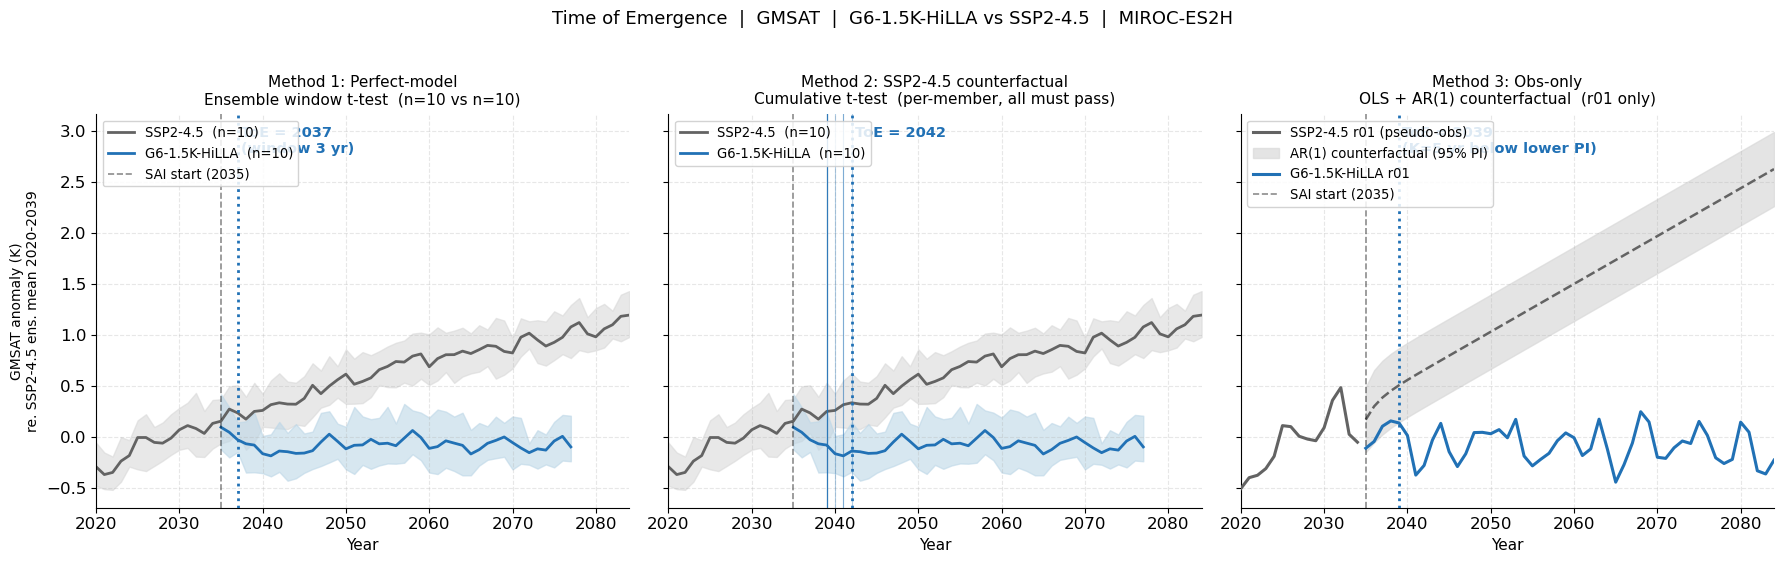


Summary
  Method 1 (perfect-model window t-test) : 2037  (window=3 yr)
  Method 2 (cumulative t-test, all 10)   : 2042
  Method 3 (obs-only AR(1), r01)         : 2039


In [11]:
BLUE       = '#2171B5'
BLUE_LIGHT = '#BDD7E7'
GRAY       = '#636363'
GRAY_LIGHT = '#D9D9D9'


def plot_ens(ax, arr, years, color, light, label, lw=2.0):
    mean = arr.mean(axis=0)
    p05  = np.percentile(arr,  5, axis=0)
    p95  = np.percentile(arr, 95, axis=0)
    ax.fill_between(years, p05, p95, color=light, alpha=0.6, zorder=1)
    ax.plot(years, mean, color=color, lw=lw, label=label, zorder=2)


def mark_toe(ax, toe, color, extra=''):
    ax.axvline(toe, color=color, lw=2.0, ls=':', zorder=5)
    ax.text(toe + 0.4, 0.97, f'ToE = {toe}{extra}',
            transform=ax.get_xaxis_transform(),
            color=color, fontsize=10.5, va='top', fontweight='bold')


fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
fig.subplots_adjust(wspace=0.06)

xlim = (PLOT_START, PLOT_END)

# ── Panel 1: perfect-model ─────────────────────────────────────────────────────
ax = axes[0]
plot_ens(ax, ssp_arr[:,  ssp_yrs  >= PLOT_START], ssp_yrs[ssp_yrs >= PLOT_START],
         GRAY, GRAY_LIGHT, 'SSP2-4.5  (n=10)')
plot_ens(ax, hilla_arr, hilla_yrs, BLUE, BLUE_LIGHT, 'G6-1.5K-HiLLA  (n=10)')
ax.axvline(SAI_START, color='k', lw=1.2, ls='--', alpha=0.45, label='SAI start (2035)')
if pm_toe:
    mark_toe(ax, pm_toe, BLUE, extra=f'\n(window {pm_wlen} yr)')
ax.set_title('Method 1: Perfect-model\n'
             'Ensemble window t-test  (n=10 vs n=10)', fontsize=11, pad=7)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('GMSAT anomaly (K)\nre. SSP2-4.5 ens. mean 2020-2039', fontsize=10)
ax.legend(fontsize=9.5, loc='upper left', framealpha=0.85)
ax.set_xlim(*xlim)
ax.grid(ls='--', alpha=0.3)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)

# ── Panel 2: cumulative t-test ─────────────────────────────────────────────────
ax = axes[1]
plot_ens(ax, ssp_arr[:, ssp_yrs >= PLOT_START], ssp_yrs[ssp_yrs >= PLOT_START],
         GRAY, GRAY_LIGHT, 'SSP2-4.5  (n=10)')
plot_ens(ax, hilla_arr, hilla_yrs, BLUE, BLUE_LIGHT, 'G6-1.5K-HiLLA  (n=10)')
ax.axvline(SAI_START, color='k', lw=1.2, ls='--', alpha=0.45)
# Mark individual member ToEs as thin ticks along the top
for mt in cm_mem_toes:
    if mt is not None:
        ax.axvline(mt, color=BLUE, lw=0.8, ls='-', alpha=0.35, zorder=3)
if cm_toe:
    mark_toe(ax, cm_toe, BLUE)
ax.set_title('Method 2: SSP2-4.5 counterfactual\n'
             'Cumulative t-test  (per-member, all must pass)', fontsize=11, pad=7)
ax.set_xlabel('Year', fontsize=11)
ax.tick_params(labelleft=False)
ax.legend(fontsize=9.5, loc='upper left', framealpha=0.85)
ax.set_xlim(*xlim)
ax.grid(ls='--', alpha=0.3)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)

# ── Panel 3: obs-only AR(1) ────────────────────────────────────────────────────
ax = axes[2]
# SSP245 r01 pseudo-obs (2020–2034)
obs_plot = miroc_ssp245_anom[0].sel(time=slice(PLOT_START, SAI_START - 1))
ax.plot(obs_plot.time.values, obs_plot.values,
        color=GRAY, lw=2.2, label='SSP2-4.5 r01 (pseudo-obs)', zorder=3)
# AR(1) counterfactual
ax.fill_between(PRED_YEARS, ar1_lo, ar1_hi,
                color=GRAY_LIGHT, alpha=0.7, zorder=1,
                label=f'AR(1) counterfactual ({int(CI_LEVEL*100)}% PI)')
ax.plot(PRED_YEARS, ar1_mu, color=GRAY, lw=1.8, ls='--', zorder=2)
# HiLLA r01
h_r01 = miroc_HiLLA_anom[0].sel(time=slice(SAI_START, PLOT_END))
ax.plot(h_r01.time.values, h_r01.values,
        color=BLUE, lw=2.2, label='G6-1.5K-HiLLA r01', zorder=4)
ax.axvline(SAI_START, color='k', lw=1.2, ls='--', alpha=0.45, label='SAI start (2035)')
if obs_toe:
    mark_toe(ax, obs_toe, BLUE, extra=f'\n(K={K_CONSEC} yr below lower PI)')
ax.set_title('Method 3: Obs-only\n'
             'OLS + AR(1) counterfactual  (r01 only)', fontsize=11, pad=7)
ax.set_xlabel('Year', fontsize=11)
ax.tick_params(labelleft=False)
ax.legend(fontsize=9.5, loc='upper left', framealpha=0.85)
ax.set_xlim(*xlim)
ax.grid(ls='--', alpha=0.3)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)

fig.suptitle(
    'Time of Emergence  |  GMSAT  |  G6-1.5K-HiLLA vs SSP2-4.5  |  MIROC-ES2H',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('Figures/ToE_three_panel.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nSummary')
print(f'  Method 1 (perfect-model window t-test) : {pm_toe}  (window={pm_wlen} yr)')
print(f'  Method 2 (cumulative t-test, all 10)   : {cm_toe}')
print(f'  Method 3 (obs-only AR(1), r01)         : {obs_toe}')

---
## Second figure: all 10 members individually, median ToE

Methods 2 and 3 are now applied to each of the 10 ensemble members independently.
The figure shows r01 as a thick dotted example line and r02–r10 as thin lines.
Results are quoted as the **median individual member ToE** across the 10 members.

In [12]:
# ── Method 2: median of individual member ToEs (already computed above) ────────
cm_median_toe = int(np.median([t for t in cm_mem_toes if t is not None]))
print(f'Method 2 member ToEs : {cm_mem_toes}')
print(f'Method 2 median ToE  : {cm_median_toe}')

# ── Method 3: run AR(1) independently for each of the 10 member pairs ─────────
print(f'\nMethod 3 — AR(1) per member (training 2020–{SAI_START - 1}):')
obs_toes_all   = []
ar1_results_all = []   # list of (mu, lo, hi) per member

for i in range(N_MEM):
    obs_i        = miroc_ssp245_anom[i].sel(time=slice(2020, SAI_START - 1))
    mu_i, lo_i, hi_i = ar1_forecast(obs_i, PRED_YEARS)
    toe_i        = ar1_toe_lower(miroc_HiLLA_anom[i], PRED_YEARS, lo_i)
    obs_toes_all.append(toe_i)
    ar1_results_all.append((mu_i, lo_i, hi_i))
    print(f'  r{i+1:02d}: ToE = {toe_i}')

obs_median_toe = int(np.median([t for t in obs_toes_all if t is not None]))
print(f'Method 3 member ToEs : {obs_toes_all}')
print(f'Method 3 median ToE  : {obs_median_toe}')

Method 2 member ToEs : [2041, 2039, 2039, 2042, 2039, 2039, 2039, 2041, 2039, 2040]
Method 2 median ToE  : 2039

Method 3 — AR(1) per member (training 2020–2034):
  OLS slope : 0.0469 K/yr  |  AR(1) phi=0.474,  sigma=0.1635 K
  r01: ToE = 2039
  OLS slope : 0.0331 K/yr  |  AR(1) phi=0.298,  sigma=0.1567 K
  r02: ToE = 2037
  OLS slope : 0.0323 K/yr  |  AR(1) phi=0.633,  sigma=0.0974 K
  r03: ToE = 2035
  OLS slope : 0.0199 K/yr  |  AR(1) phi=0.312,  sigma=0.1690 K
  r04: ToE = 2059
  OLS slope : 0.0383 K/yr  |  AR(1) phi=0.417,  sigma=0.1371 K
  r05: ToE = 2037
  OLS slope : 0.0267 K/yr  |  AR(1) phi=0.393,  sigma=0.2055 K
  r06: ToE = 2043
  OLS slope : 0.0434 K/yr  |  AR(1) phi=0.386,  sigma=0.1490 K
  r07: ToE = 2037
  OLS slope : 0.0446 K/yr  |  AR(1) phi=0.285,  sigma=0.1402 K
  r08: ToE = 2040
  OLS slope : 0.0361 K/yr  |  AR(1) phi=0.303,  sigma=0.1463 K
  r09: ToE = 2039
  OLS slope : 0.0226 K/yr  |  AR(1) phi=0.338,  sigma=0.1737 K
  r10: ToE = 2042
Method 3 member ToEs : [203

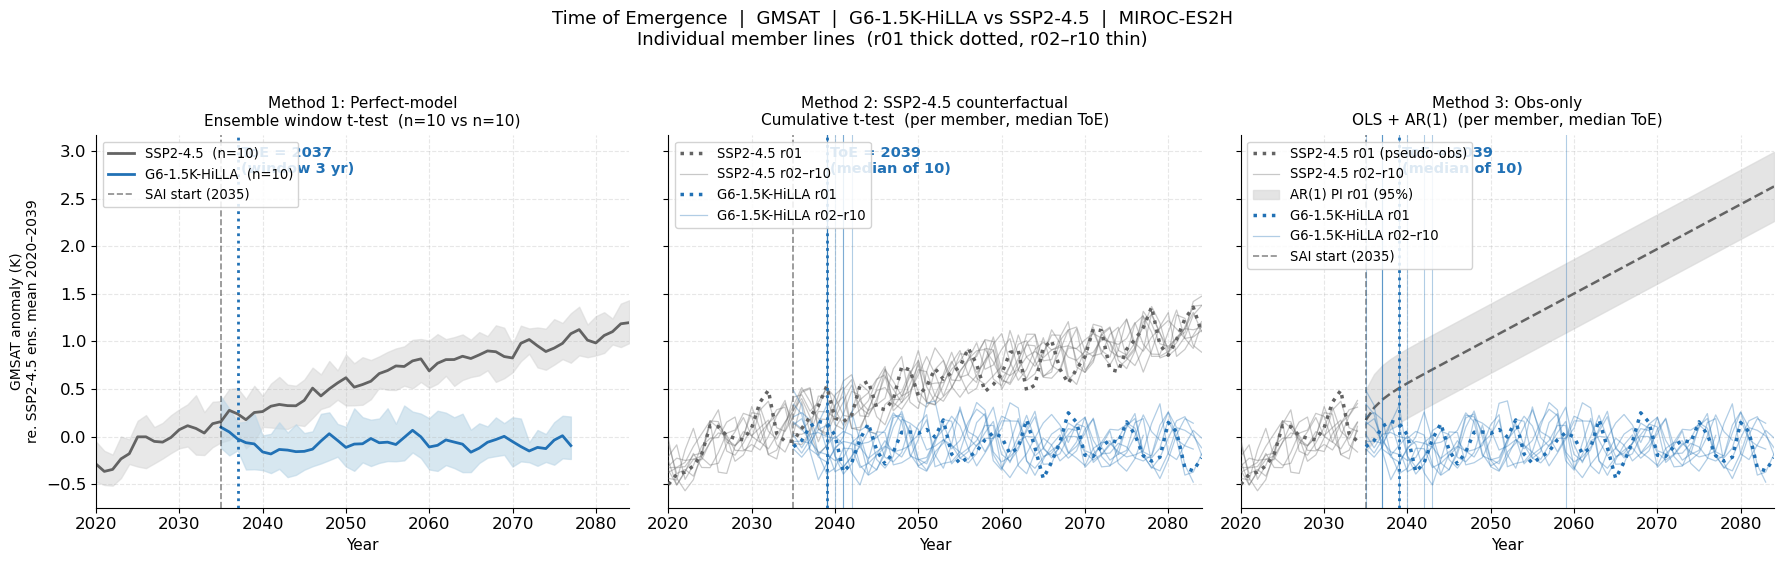


Summary (median of 10 individual member ToEs)
  Method 1 (perfect-model window t-test) : 2037  (window=3 yr, unchanged)
  Method 2 (cumulative t-test)           : 2039
  Method 3 (obs-only AR(1))              : 2039


In [13]:
EXAMPLE_IDX = 0   # r01 is the highlighted example member


def plot_members(ax, ts_list, color, yr_start=PLOT_START, yr_end=PLOT_END,
                 label_ex='', label_oth=''):
    """Plot example member as thick dotted, all others as thin solid."""
    for i, ts in enumerate(ts_list):
        yrs  = ts.time.values
        mask = (yrs >= yr_start) & (yrs <= yr_end)
        if i == EXAMPLE_IDX:
            ax.plot(yrs[mask], ts.values[mask], color=color,
                    lw=2.5, ls=':', alpha=1.0, zorder=4,
                    label=label_ex)
        else:
            ax.plot(yrs[mask], ts.values[mask], color=color,
                    lw=0.9, ls='-', alpha=0.35, zorder=3,
                    label=label_oth if i == 1 else '_')


fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
fig2.subplots_adjust(wspace=0.06)

# ── Panel 1: perfect-model (unchanged) ────────────────────────────────────────
ax = axes2[0]
plot_ens(ax, ssp_arr[:, ssp_yrs >= PLOT_START], ssp_yrs[ssp_yrs >= PLOT_START],
         GRAY, GRAY_LIGHT, 'SSP2-4.5  (n=10)')
plot_ens(ax, hilla_arr, hilla_yrs, BLUE, BLUE_LIGHT, 'G6-1.5K-HiLLA  (n=10)')
ax.axvline(SAI_START, color='k', lw=1.2, ls='--', alpha=0.45, label='SAI start (2035)')
if pm_toe:
    mark_toe(ax, pm_toe, BLUE, extra=f'\n(window {pm_wlen} yr)')
ax.set_title('Method 1: Perfect-model\nEnsemble window t-test  (n=10 vs n=10)',
             fontsize=11, pad=7)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('GMSAT anomaly (K)\nre. SSP2-4.5 ens. mean 2020–2039', fontsize=10)
ax.legend(fontsize=9.5, loc='upper left', framealpha=0.85)
ax.set_xlim(PLOT_START, PLOT_END)
ax.grid(ls='--', alpha=0.3)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)

# ── Panel 2: individual member lines, median ToE ──────────────────────────────
ax = axes2[1]
plot_members(ax, miroc_ssp245_anom, GRAY,
             label_ex='SSP2-4.5 r01',
             label_oth='SSP2-4.5 r02–r10')
plot_members(ax, miroc_HiLLA_anom, BLUE,
             label_ex='G6-1.5K-HiLLA r01',
             label_oth='G6-1.5K-HiLLA r02–r10')
ax.axvline(SAI_START, color='k', lw=1.2, ls='--', alpha=0.45)
# thin vertical ticks for each individual member ToE
for mt in cm_mem_toes:
    if mt is not None:
        ax.axvline(mt, color=BLUE, lw=0.8, ls='-', alpha=0.35, zorder=3)
mark_toe(ax, cm_median_toe, BLUE, extra='\n(median of 10)')
ax.set_title('Method 2: SSP2-4.5 counterfactual\nCumulative t-test  (per member, median ToE)',
             fontsize=11, pad=7)
ax.set_xlabel('Year', fontsize=11)
ax.tick_params(labelleft=False)
ax.legend(fontsize=9.5, loc='upper left', framealpha=0.85)
ax.set_xlim(PLOT_START, PLOT_END)
ax.grid(ls='--', alpha=0.3)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)

# ── Panel 3: all-member AR(1), r01 PI band highlighted ────────────────────────
ax = axes2[2]

# SSP245 pseudo-obs training period (2020–2034)
plot_members(ax, miroc_ssp245_anom, GRAY,
             yr_end=SAI_START - 1,
             label_ex='SSP2-4.5 r01 (pseudo-obs)',
             label_oth='SSP2-4.5 r02–r10')

# r01 AR(1) PI band (example member)
mu0, lo0, hi0 = ar1_results_all[EXAMPLE_IDX]
ax.fill_between(PRED_YEARS, lo0, hi0,
                color=GRAY_LIGHT, alpha=0.7, zorder=1,
                label=f'AR(1) PI r01 ({int(CI_LEVEL*100)}%)')
ax.plot(PRED_YEARS, mu0, color=GRAY, lw=1.8, ls='--', zorder=2)

# all 10 HiLLA member lines
plot_members(ax, miroc_HiLLA_anom, BLUE,
             yr_start=SAI_START,
             label_ex='G6-1.5K-HiLLA r01',
             label_oth='G6-1.5K-HiLLA r02–r10')

ax.axvline(SAI_START, color='k', lw=1.2, ls='--', alpha=0.45, label='SAI start (2035)')
# thin ticks for each member's ToE
for ot in obs_toes_all:
    if ot is not None:
        ax.axvline(ot, color=BLUE, lw=0.8, ls='-', alpha=0.35, zorder=3)
mark_toe(ax, obs_median_toe, BLUE, extra='\n(median of 10)')
ax.set_title('Method 3: Obs-only\nOLS + AR(1)  (per member, median ToE)',
             fontsize=11, pad=7)
ax.set_xlabel('Year', fontsize=11)
ax.tick_params(labelleft=False)
ax.legend(fontsize=9.5, loc='upper left', framealpha=0.85)
ax.set_xlim(PLOT_START, PLOT_END)
ax.grid(ls='--', alpha=0.3)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)

fig2.suptitle(
    'Time of Emergence  |  GMSAT  |  G6-1.5K-HiLLA vs SSP2-4.5  |  MIROC-ES2H\n'
    'Individual member lines  (r01 thick dotted, r02–r10 thin)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('Figures/ToE_three_panel_members.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nSummary (median of 10 individual member ToEs)')
print(f'  Method 1 (perfect-model window t-test) : {pm_toe}  (window={pm_wlen} yr, unchanged)')
print(f'  Method 2 (cumulative t-test)           : {cm_median_toe}')
print(f'  Method 3 (obs-only AR(1))              : {obs_median_toe}')